
# TP Diffusion Models (RLD course)

This exercise notebook will guide through the definition of a simple diffusion
model (for MNIST)

A good overview can be found in
[Lil'Log](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)
from which most of the formulas of this notebook are taken.

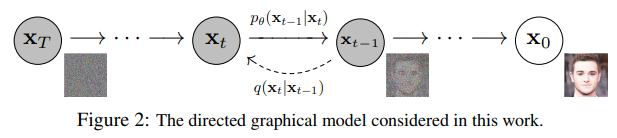

In [ ]:

try:
    import google.colab

    !pip install easypip
    import easypip

    easypip.install("torch>=1.12")
    easypip.install("torchvision")
    easypip.install("matplotlib")
    easypip.install("einops")

    print("Restarting of kernel...")
    #get_ipython().kernel.do_shutdown(True)
except ModuleNotFoundError:
    pass

[easypip] Installing torch>=1.12
[easypip] Installing torchvision


Restarting of kernel...


[easypip] Installing matplotlib
[easypip] Installing einops


In [ ]:


# Import the necessary modules
from typing import Optional
from functools import partial
import math

from tqdm.autonotebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

%matplotlib inline
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/tmp/ipython-input-3980530312.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:

# Main experimental settings
timesteps = 200
epochs = 5

# Loading the dataset
In this notebook, we will look at images from MNIST - but you can redefine this dataset
to learn from other image distributions

In [ ]:

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor()  # Converts to [0, 1] range and adds channel dimension
])

train_data = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Get image properties for model initialization
sample_image = train_data[0][0]
image_channels = sample_image.shape[0]  # Should be 1 for grayscale MNIST
image_shape = sample_image.shape[1:]  # (28, 28)

In [ ]:

import os
if os.environ.get("TESTING_MODE", "off") == "ON":
    timesteps = 5
    epochs = 1
    # Use a subset for testing
    train_data = torch.utils.data.Subset(train_data, range(100))
    plt.show = lambda *args, **kwargs: None

# Displaying images
To visualize the results, we use the `show_image` function that takes
a batch of images (N, 1, H, W) if grayscale or (N, 3, H, W) for RGB

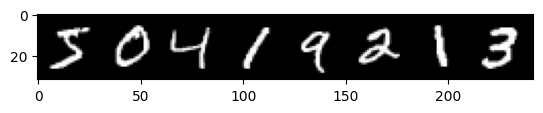

In [ ]:


def show_images(images, nrow=8):
    """Show images

    Args:
        images (torch.Tensor): The batch of images
        nrow (int, optional): The number of images per row. Defaults to 8.
    """
    images_3c = images.repeat(1, 3, 1, 1) if images.shape[1] != 3 else images
    images_3c = images_3c.double().clamp(0, 1)
    grid = make_grid(images_3c, nrow=nrow).permute((1, 2, 0))
    plt.imshow(grid)
    plt.show()


# Now, show some images from the training set
sample_images = torch.stack([train_data[i][0] for i in range(8)])
show_images(sample_images)


# Diffusion Process

Let $q(\mathbf{x}_0)$ be the real data distribution, say of "real images". We
can sample from this distribution to get an image, $\mathbf{x}_0 \sim
q(\mathbf{x}_0)$. We define the forward diffusion process $q(\mathbf{x}_t |
\mathbf{x}_{t-1})$ which adds Gaussian noise at each time step $t$, according
to a known variance schedule $0 < \beta_1 < \beta_2 < ... < \beta_T < 1$ as
$$ q(\mathbf{x}_t | \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 -
\beta_t} \mathbf{x}_{t-1}, \beta_t \mathbf{I}). $$

Said otherwise, $$ \mathbf{x}_t = \sqrt{1 - \beta_t} \mathbf{x}_{t-1} +
\sqrt{\beta_t} \epsilon $$ with $\epsilon \sim \mathcal N(0, \mathbf{I})$.

# Schedules

There were many propositions to set the $\beta_t$ - whose general name is
*schedule*. Some are defined below:

- `LinearSchedule`
- `QuadraticSchedule`
- `SigmoidSchedule`


In [ ]:


class Schedule:
    def __init__(self, betas):
        # Store basic information
        self.timesteps = len(betas)
        self.betas = betas
        self.alphas = 1.0 - betas

        # Pre-compute useful values:
        # use them in your code!
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)

        self.alphas_cumprod_prev = nn.functional.pad(
            self.alphas_cumprod[:-1], (1, 0), value=1.0
        )

        self.posterior_variance = (
            betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )


class LinearSchedule(Schedule):
    def __init__(self, timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        super().__init__(torch.linspace(beta_start, beta_end, timesteps))


class QuadraticSchedule(Schedule):
    def __init__(self, timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        super().__init__(
            torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2
        )


class SigmoidSchedule(Schedule):
    def __init__(self, timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        super().__init__(torch.sigmoid(betas) * (beta_end - beta_start) + beta_start)

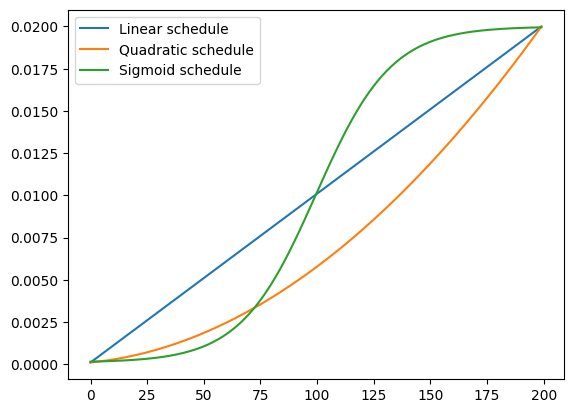

In [ ]:

# Display the schedules


plt.plot(LinearSchedule(timesteps).betas, label="Linear schedule")
plt.plot(QuadraticSchedule(timesteps).betas, label="Quadratic schedule")
plt.plot(SigmoidSchedule(timesteps).betas, label="Sigmoid schedule")
plt.legend()
plt.show()


In many places, we need to take time specific values (from the schedule $\beta_t$)
or one of the derived values. The function `temporal_gather` can be used
for such manipulations:

In [ ]:

def temporal_gather(a: torch.Tensor, t: torch.LongTensor, x_shape):
    """Gather values from tensor `a` using indices from `t`.

    Adds dimensions at the end of the tensor to match with the number of dimensions
    of `x_shape`
    """
    batch_size = len(t)
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [ ]:

# Example of use

temporal_gather(
    # The tensor from which we gather values
    torch.Tensor([1.1, 1.2, 1.3, 1.4]),
    # The time tensor
    torch.LongTensor([0, 1, 1, 0, 2]),
    # Just a shape...
    torch.zeros(1, 5, 3).shape,
)

tensor([[[1.1000]],

        [[1.2000]],

        [[1.2000]],

        [[1.1000]],

        [[1.3000]]])


# Sampling $q(x_t|x_0)$
A direct consequence of the constructed forward process $q$, as shown by [(Sohl-Dickstein et al., 2015)](https://arxiv.org/abs/1503.03585), is that we can sample $\mathbf{x}_t$ at any arbitrary noise level conditioned on $\mathbf{x}_0$ (since a sum of Gaussians is also Gaussian). This is very convenient:  we don't need to apply $q$ repeatedly in order to sample $\mathbf{x}_t$.
We have that
$$q(\mathbf{x}_t | \mathbf{x}_0) = \cal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1- \bar{\alpha}_t) \mathbf{I})$$
with $$\alpha_t = 1 - \beta_t\ \textrm{ and }\ \bar{\alpha}_t = \Pi_{s=1}^{t} \alpha_s$$

Let's refer to this equation as the "nice property". This means we can sample Gaussian noise and scale it appropriately and add it to $\mathbf{x}_0$ to get $\mathbf{x}_t$ directly. Note that the $\bar{\alpha}_t$ are functions of the known $\beta_t$ variance schedule and thus are also known and can be precomputed. This then allows us, during training, to **optimize random terms of the loss function $L$** (or in other words, to randomly sample $t$ during training and optimize $L$.

In [ ]:
def q_sample(schedule: Schedule, x_0: torch.Tensor, t: torch.LongTensor, noise: Optional[torch.Tensor]=None):
    """Sample q(x_t|x_0) for a batch

    Args:
        schedule (Schedule): The $\beta_t$ schedule

        x_0 (torch.Tensor): A batch of images (N, C, W, H)

        t (torch.Tensor): A 1D tensor of integers (time)

        noise (torch.Tensor, optional): Sampled noise of the same dimension than
        x_0; if not given, sample one. Defaults to None.
    """
    if noise is None:
        noise = torch.randn_like(x_0)

    sqrt_alphas_cumprod_t = temporal_gather(schedule.sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = temporal_gather(schedule.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * e
    x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise

    return x_t

# Check that everything is all right
x_0 =  torch.Tensor([[2.3, 1.2, 4.2], [5.4, 3.2, 1.4]])
noise = torch.Tensor([[ 0.4938392937,  0.5089217424,  1.4516087770],
        [-1.1347782612, -1.3416436911, -0.1392416954]])
expected = torch.Tensor([[2.3507647514, 1.2699846029, 4.3878836632],
        [5.3043818474, 3.0952007771, 1.3863569498]])
t = torch.LongTensor([3, 1])
observed = q_sample(LinearSchedule(5), x_0, t, noise=noise)
assert torch.allclose(observed, expected)

We can now show various samples with various $t$

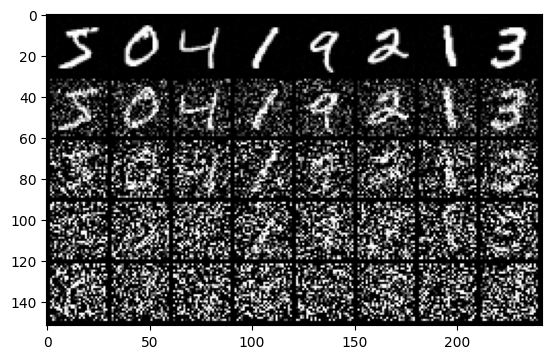

In [ ]:

schedule = LinearSchedule(timesteps)
sample = torch.stack([train_data[i][0] for i in range(8)])

images = []
for t in [0, timesteps // 4, 2 * (timesteps // 4), 3 * (timesteps // 4), timesteps-1]:
    x_t = q_sample(schedule, sample, torch.LongTensor([t]))
    images.append(x_t)

show_images(torch.cat(images))

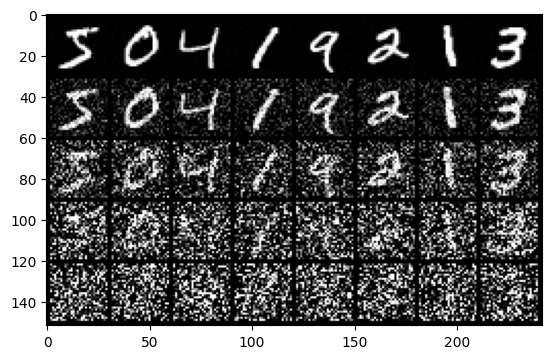

In [ ]:

schedule = QuadraticSchedule(timesteps)
sample = torch.stack([train_data[i][0] for i in range(8)])

images = []
for t in [0, timesteps // 4, 2 * (timesteps // 4), 3 * (timesteps // 4), timesteps-1]:
    x_t = q_sample(schedule, sample, torch.LongTensor([t]))
    images.append(x_t)

show_images(torch.cat(images))

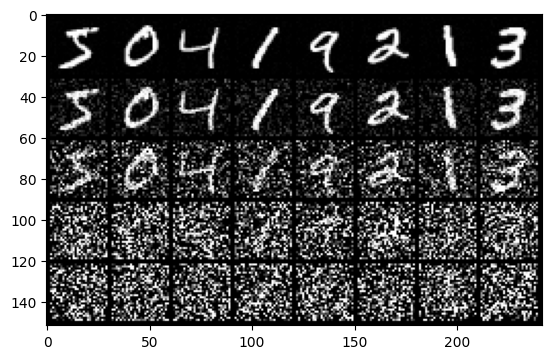

In [ ]:

schedule = SigmoidSchedule(timesteps)
sample = torch.stack([train_data[i][0] for i in range(8)])

images = []
for t in [0, timesteps // 4, 2 * (timesteps // 4), 3 * (timesteps // 4), timesteps-1]:
    x_t = q_sample(schedule, sample, torch.LongTensor([t]))
    images.append(x_t)

show_images(torch.cat(images))


# Training

Now that we can generate samples at various time steps, we now turn to
training diffusion models, that is, we want to learn the parametric
distributions $$p_\theta(\mathbf{x}_{t-1} \vert \mathbf{x}_t) =
\mathcal{N}(\mathbf{x}_{t-1}; \boldsymbol{\mu}_\theta(\mathbf{x}_t, t),
\boldsymbol{\Sigma}_\theta(\mathbf{x}_t, t))$$

$$\begin{aligned}
NLL = - \log p_\theta(\mathbf{x}_0)
&\leq - \log p_\theta(\mathbf{x}_0) + D_\text{KL}(q(\mathbf{x}_{1:T}\vert\mathbf{x}_0) \| p_\theta(\mathbf{x}_{1:T}\vert\mathbf{x}_0) ) \\
&= \mathbb{E}_q \Big[ \log \frac{q(\mathbf{x}_{1:T}\vert\mathbf{x}_0)}{p_\theta(\mathbf{x}_{0:T})} \Big] =  L_{\mathrm{VLB}} \\
\end{aligned}$$
It can be shown that
$$
L_{\mathrm{VLB}} = \mathbb{E}_q [\underbrace{D_\text{KL}(q(\mathbf{x}_T \vert \mathbf{x}_0) \parallel p_\theta(\mathbf{x}_T))}_{L_T} + \sum_{t=2}^T \underbrace{D_\text{KL}(q(\mathbf{x}_{t-1} \vert \mathbf{x}_t, \mathbf{x}_0) \parallel p_\theta(\mathbf{x}_{t-1} \vert\mathbf{x}_t))}_{L_{t-1}} \underbrace{- \log p_\theta(\mathbf{x}_0 \vert \mathbf{x}_1)}_{L_0} ]
$$
where $L$ is constant (since $x_T$ is by hypothesis Gaussian noise) wrt parameters ($q$ has no parameters). The term $L_{t-1}$ is a KL divergence between two Gaussians and can be computed in *closed form*.


## Reparametrization trick


As shown in [(Ho et al., 2021)](https://arxiv.org/abs/2106.15282) is that one
can instead reparametrize the mean to make the neural network learn (predict)
the added noise via a network $\mathbf{\epsilon}_\theta(\mathbf{x}_t, t)$ for
noise level $t$.

Said otherwise,
$$
\mathbf{x}_{t-1} \vert \mathbf{x}_t \sim \mathcal{N}\left( \frac{1}{\sqrt{\alpha_t}} \Big( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \Big), \boldsymbol{\Sigma}_\theta(\mathbf{x}_t, t)\right)
$$


The final objective function $L$ - with some extra simplifications
as shown in [(Ho et al., 2021)](https://arxiv.org/abs/2106.15282),
is simply:
$$ L = \mathbb{E}_{x_0 \sim q, t \sim \mathcal U(\{1,\ldots, T\})} \|
\mathbf{\epsilon} - \mathbf{\epsilon}_\theta( \sqrt{\bar{\alpha}_t}
\mathbf{x}_0 + \sqrt{(1- \bar{\alpha}_t)  } \mathbf{\epsilon}, t) \|^2$$


# Defining the noise model

We are now interested in defining the function $\epsilon_\theta(\mathbf{x}, t)$.
To represent time, we use positional embeddings similar to those
used to define transformers.
The code is the cell below defines a `SinusoidalPositionEmbeddings`
module that computes the embeddings of a vector of time

In [ ]:


class SinusoidalPositionEmbeddings(nn.Module):
    """Positional embeddings"""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        assert dim % 2 == 0, "Positional embeddings should be multiples of 2"

    def forward(self, time: torch.Tensor):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# Example of use
t_emb = SinusoidalPositionEmbeddings(10)
t_emb(torch.LongTensor([5, 3, 2])).shape

torch.Size([3, 10])


# Image Generation: U-Net

The consensus is to use an architecture derived from U-Net, a model used
for image segmentation. The code in the next block correspond
to this model. You do not need to read the code itself (unless
you really want to).

The U-Net model has been modified in order to take as
input a time embeddings that modifies its output.

In [ ]:

# Define the UNet architecture

from einops import rearrange
from torch import einsum


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )
        q = q * self.scale

        sim = einsum("b h d i, b h d j -> b h i j", q, k)
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)

        out = einsum("b h i j, b h d j -> b h i d", attn, v)
        out = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1), nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(
            lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv
        )

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


def defined(x):
    return x is not None


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, kernel_size=4, stride=2, padding=1)


def Downsample(dim):
    return nn.Conv2d(dim, dim, kernel_size=4, stride=2, padding=1)


class Block(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)

        if defined(scale_shift):
            assert False, "I thought you would not come here"
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x


class ResnetBlock(nn.Module):
    """https://arxiv.org/abs/1512.03385"""

    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if time_emb_dim
            else None
        )

        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x: torch.Tensor, time_emb=None):
        h = self.block1(x)

        if defined(self.mlp) and defined(time_emb):
            time_emb = self.mlp(time_emb)
            # h = rearrange(time_emb, "b c -> b c 1 1") + h
            h = time_emb.unsqueeze(-1).unsqueeze(-1) + h

        h = self.block2(h)
        return h + self.res_conv(x)


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)


class Unet(nn.Module):
    def __init__(
        self,
        dim,
        *,
        init_dim=None,
        out_dim=None,
        dim_mults=(
            1,
            2,
            4,
        ),
        channels=3,
        time_dim=None,
        resnet_block_groups=4,
    ):
        """Unet architecture

        Args:
            dim (int): The dimension of the image (assumes a square image)
            init_dim (int, optional): The initialisation. Defaults to `dim // 3 * 2`.
            out_dim (int, optional): The output dimension. Defaults to channels.
            dim_mults (tuple, optional): List of ints. Defaults to (1, 2, 4).
            channels (int, optional): The number of input channels. Defaults to 3.
            time_dim (bool, optional): Time embeddings dimension. Defaults to None.
            resnet_block_groups (int, optional): Number of groups for ResNet layer normalization. Defaults to 8.
        """
        super().__init__()

        # determine dimensions
        self.channels = channels
        self.time_dim = time_dim

        # First convolution
        init_dim = init_dim or (dim // 3 * 2)
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)

        dims = [init_dim, *(dim * m for m in dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        resnet_block = partial(ResnetBlock, groups=resnet_block_groups)

        # layers
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append(
                nn.ModuleList(
                    [
                        resnet_block(dim_in, dim_out, time_emb_dim=time_dim),
                        resnet_block(dim_out, dim_out, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                        Downsample(dim_out) if not is_last else nn.Identity(),
                    ]
                )
            )

        mid_dim = dims[-1]
        self.mid_block1 = resnet_block(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = resnet_block(mid_dim, mid_dim, time_emb_dim=time_dim)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (num_resolutions - 1)

            self.ups.append(
                nn.ModuleList(
                    [
                        resnet_block(dim_out * 2, dim_in, time_emb_dim=time_dim),
                        resnet_block(dim_in, dim_in, time_emb_dim=time_dim),
                        Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                        Upsample(dim_in) if not is_last else nn.Identity(),
                    ]
                )
            )

        out_dim = out_dim or channels
        self.final_conv = nn.Sequential(
            resnet_block(dim, dim), nn.Conv2d(dim, out_dim, 1)
        )

    def forward(self, x, t: Optional[torch.Tensor] = None):
        assert defined(t) or not defined(self.time_dim), "No time embeddings given"

        x = self.init_conv(x)
        h = []

        # downsample
        for block1, block2, attn, downsample in self.downs:
            x = block1(x, t)
            x = block2(x, t)
            x = attn(x)
            h.append(x)
            x = downsample(x)

        # bottleneck
        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        # upsample
        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = block1(x, t)
            x = block2(x, t)
            x = attn(x)
            x = upsample(x)

        return self.final_conv(x)

# Example of use
images = train_data[0][0].unsqueeze(0)
unet = Unet(
    # Width/Height of image
    image_shape[0],
    # Just one channel for MNIST
    channels=1,
    # Time embeddings are in $R^d$
    time_dim=5
)


# Defining the model

In the code below, you need to define the
noise model $\epsilon_\theta$. Don't forget
to take into account the time embeddings
using one of the PositionEmbeddings classes.

In [ ]:
class Model(nn.Module):
    def __init__(self, dim, channels=1):
        """Initialize our noise model

        Args:
            dim (int): The width/height of an image
            channels (int, optional): The number of channels of the image. Defaults to 1.
        """
        super().__init__()
        self.image_size = dim
        self.channels = channels

        time_dim = dim * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.unet = Unet(
            dim,
            channels=channels,
            time_dim=time_dim
        )

    def forward(self, x_t, time):
        time_emb = self.time_mlp(time)
        return self.unet(x_t, time_emb)

# Initialize the model
model = Model(image_shape[0], image_channels)
model.to(device)

Model(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=28, out_features=112, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=112, out_features=112, bias=True)
  )
  (unet): Unet(
    (init_conv): Conv2d(1, 18, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (downs): ModuleList(
      (0): ModuleList(
        (0): ResnetBlock(
          (mlp): Sequential(
            (0): SiLU()
            (1): Linear(in_features=112, out_features=28, bias=True)
          )
          (block1): Block(
            (proj): Conv2d(18, 28, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): GroupNorm(4, 28, eps=1e-05, affine=True)
            (act): SiLU()
          )
          (block2): Block(
            (proj): Conv2d(28, 28, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): GroupNorm(4, 28, eps=1e-05, affine=True)
            (act): SiLU()
          )
          (res_conv): Conv2d(18, 28,


# Sampling

Before writing the training loop, we first set up the sampling
function - that is, the procedure that generates an image
from Gaussion noise.

You will need to complete the functions `sample` and `p_sample`.
Note that we work with batches and that `sample` returns
the images for all time steps $x_{T-1}, \ldots, x_{0}$.

The function `sample` handles the main decoding loop:

- Sample $X_T \sim \mathcal N(\mathbf 0, \mathbf I)$
- For $t=T,\ldots,1$ compute $x_{t-1} = \mathrm{p\_sample}(x_{t}, t)$
- Return $x_0$

where the function `p_sample`, that you will code, is defined by:
1. If $t>1$, sample $\mathbf z \sim \mathcal N(\mathbf 0, \mathbf I)$, else $z = \mathbf 0$
1. $x_{t-1} = \frac 1 {\sqrt{\alpha_t}} \left( \mathbf x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}} \mathbf{\epsilon}_\theta(\mathbf{x}_t, t)  \right) + \sigma_t \mathbf z$ with $$\sigma_t^2 = \beta_t \times \frac{1-\bar\alpha_{t-1}}{1-\bar \alpha_t}$$

<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-4110268713.py:35: SyntaxWarning: invalid escape sequence '\l'
  List[torch.Tensor]: List of images for each time step $x_{T-1}, \ldots, x_0$


Sampling timesteps:   0%|          | 0/200 [00:00<?, ?it/s]

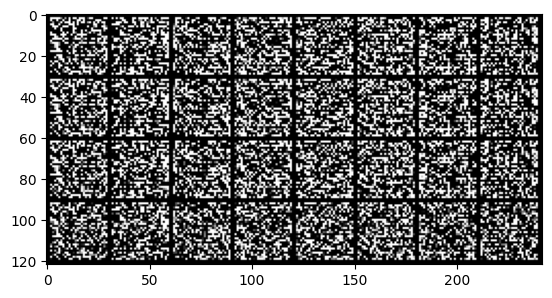

In [ ]:

@torch.no_grad()
def p_sample(schedule: Schedule, model: Model, x: torch.Tensor, t_index: int):
    betas_t = temporal_gather(schedule.betas, torch.tensor([t_index], device=x.device), x.shape)
    sqrt_one_minus_alphas_cumprod_t = temporal_gather(
        schedule.sqrt_one_minus_alphas_cumprod, torch.tensor([t_index], device=x.device), x.shape
    )
    sqrt_recip_alphas_t = temporal_gather(
        schedule.sqrt_recip_alphas, torch.tensor([t_index], device=x.device), x.shape
    )

    model_output = model(x, torch.tensor([t_index], device=x.device))
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model_output / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean

    posterior_variance_t = temporal_gather(schedule.posterior_variance, torch.tensor([t_index], device=x.device), x.shape)
    noise = torch.randn_like(x)

    x_prev = model_mean + torch.sqrt(posterior_variance_t) * noise
    return x_prev

@torch.no_grad()
def sample(schedule, model, batch_size=16):
    """Sample images from the generation model

    Args:
        schedule (Schedule): The variance schedule
        model (Model): The noise model
        batch_size (int, optional): Number of images to generate. Defaults to 16.

    Returns:
        List[torch.Tensor]: List of images for each time step $x_{T-1}, \ldots, x_0$
    """
    image_size = model.image_size
    channels = model.channels
    device = next(model.parameters()).device

    imgs = []
    x = torch.randn((batch_size, channels, image_size, image_size), device=device)
    for i in tqdm(reversed(range(schedule.timesteps)), desc='Sampling timesteps', total=schedule.timesteps):
        x = p_sample(schedule, model, x, i)
        imgs.append(x.cpu())

    return imgs

# Try to generate some images
samples = sample(schedule, model, 8)
show_images(torch.cat(samples[-1:0:-50]))


# Training loop

We are now ready to code the training loop. Note that
instead of using a L2 loss, you can use a Smooth L1
one - which is less sensitive to outliers.

We recall that the final objective function $L$ is:
$$ L = \mathbb{E}_{x_0 \sim q, t \sim \mathcal U(\{1,\ldots, T\})} \|
\mathbf{\epsilon} - \mathbf{\epsilon}_\theta( \sqrt{\bar{\alpha}_t}
\mathbf{x}_0 + \sqrt{(1- \bar{\alpha}_t)  } \mathbf{\epsilon}, t) \|^2$$

Loss: 0.5584056377410889


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 77.75it/s]


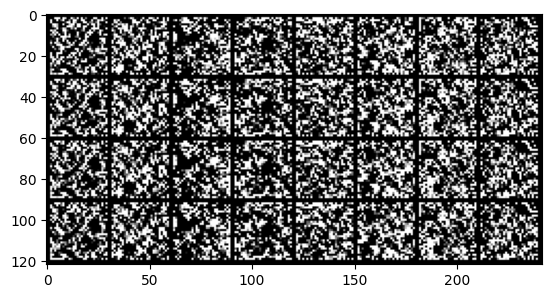

Loss: 0.33162522315979004
Loss: 0.20440194010734558
Loss: 0.1490536332130432
Loss: 0.14055341482162476
Loss: 0.1222492903470993


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 78.18it/s]


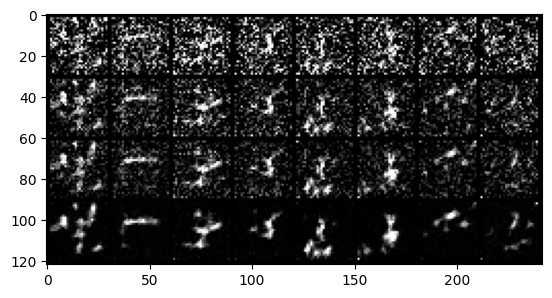

Loss: 0.1152186468243599
Loss: 0.09764589369297028
Loss: 0.09263283014297485
Loss: 0.08156754821538925
Loss: 0.08618974685668945


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 90.81it/s]


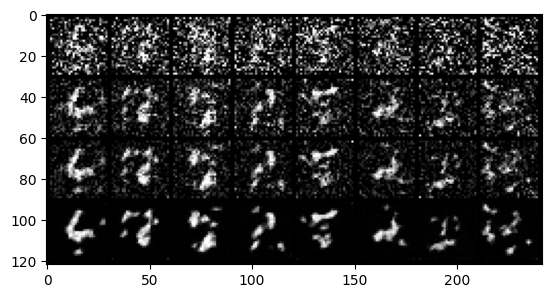

Loss: 0.08539709448814392
Loss: 0.0823139026761055
Loss: 0.07576700299978256
Loss: 0.087648905813694
Loss: 0.0674358680844307


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 92.16it/s]


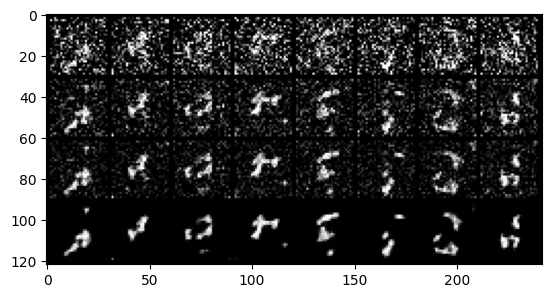

Loss: 0.06502192467451096
Loss: 0.06730460375547409
Loss: 0.06263744086027145
Loss: 0.06765688210725784
Loss: 0.058294814079999924


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 84.20it/s]


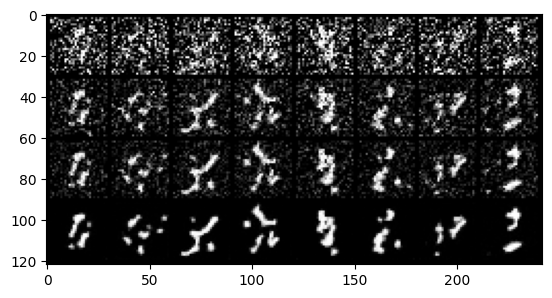

Loss: 0.06573861092329025
Loss: 0.06396665424108505
Loss: 0.07016919553279877
Loss: 0.06262492388486862
Loss: 0.05854478478431702


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 84.66it/s]


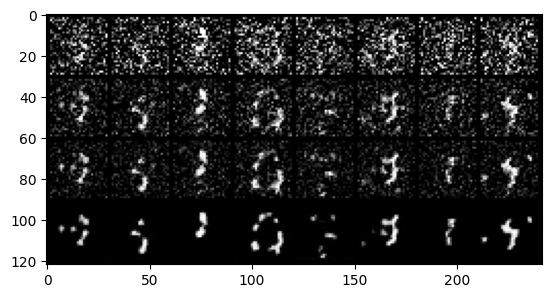

Loss: 0.05998881533741951
Loss: 0.056672465056180954
Loss: 0.06700330972671509
Loss: 0.064823679625988
Loss: 0.06768035143613815


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 88.89it/s]


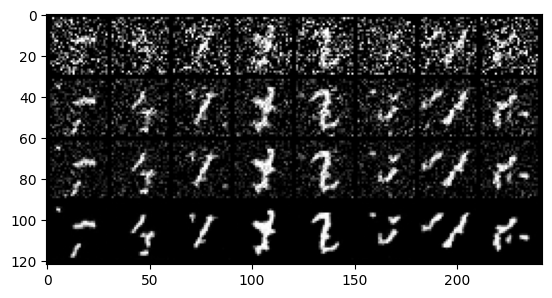

Loss: 0.06168200820684433
Loss: 0.05822812765836716
Loss: 0.05929254740476608
Loss: 0.05966929718852043
Loss: 0.06479348987340927


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 89.14it/s]


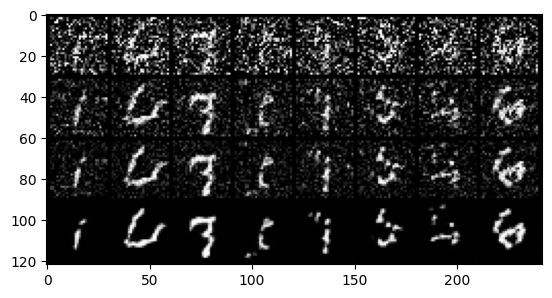

Loss: 0.053100474178791046
Loss: 0.055067792534828186
Loss: 0.06623230874538422
Loss: 0.06555844098329544
Loss: 0.06484901905059814


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 69.16it/s]


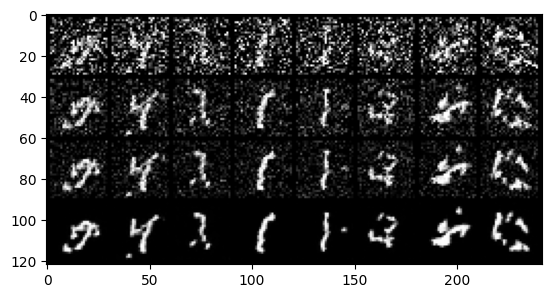

Loss: 0.06184813380241394
Loss: 0.05693183094263077
Loss: 0.05513320118188858
Loss: 0.051479317247867584
Loss: 0.059948261827230453


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 87.55it/s]


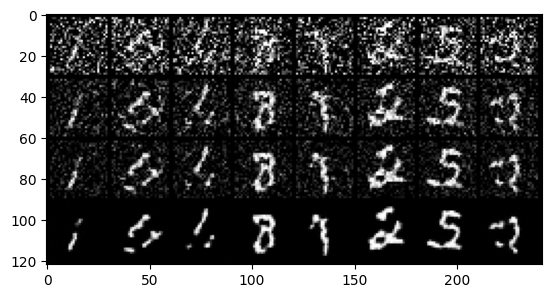

Loss: 0.0636688694357872
Loss: 0.05806291848421097
Loss: 0.050444379448890686
Loss: 0.05579492077231407


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
dataloader = DataLoader(train_data, batch_size=128, shuffle=True, pin_memory=True)
from tqdm import tqdm

for epoch in range(10):
    for step, (batch, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        batch_size = batch.shape[0]
        batch = batch.to(device)
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()
        noise = torch.randn_like(batch)
        x_t = q_sample(schedule, batch, t, noise)
        predicted_noise = model(x_t, t)
        loss = nn.functional.mse_loss(noise, predicted_noise)

        if step % 100 == 0:
            print("Loss:", loss.item())

        if step % 1000 == 0:
            image = sample(schedule, model, 8)
            show_images(
                torch.cat(
                    [
                        image[-timesteps // 2],
                        image[-timesteps // 3],
                        image[-timesteps // 4],
                        image[-1],
                    ]
                )
            )

        loss.backward()
        optimizer.step()


Sampling timesteps: 100%|██████████| 200/200 [00:02<00:00, 91.37it/s]


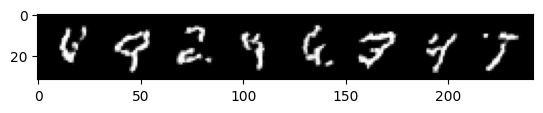

In [ ]:
samples = sample(schedule, model, 8)
show_images(samples[-1])

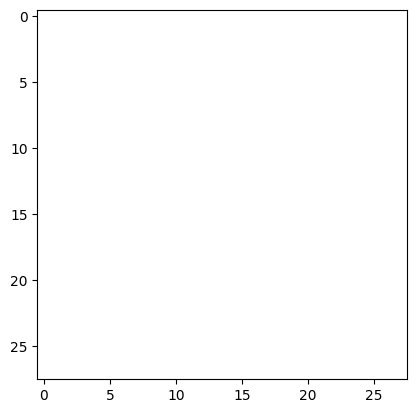

In [ ]:

import matplotlib.animation as animation

random_index = 4
image_size = image_shape[0]
channels = image_channels

fig = plt.figure()
ims = []
for i in range(timesteps):
    im = plt.imshow(
        samples[i][random_index].reshape(image_size, image_size, channels),
        cmap="gray",
        animated=True,
    )
    ims.append([im])

animate = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
plt.show()

In [ ]:

try:
    from IPython.display import HTML, display
    display(HTML(animate.to_html5_video()))
except (ModuleNotFoundError, NameError):
    # IPython not available or not in notebook environment
    pass


# Assignment: Conditional Classifier-Free Guidance

You will implement the classifier-free guidance proposed by J. Ho and T.
Salimans [1], with the class labels being 0 to 9 (the digit in MNIST).
You need to change your Noise model to include the class
label $y$ that you discard with a given probability so that the
model can generate samples without class information, that is
$$\mathbf{\epsilon}_\theta(\mathbf{x}_t, t, y)$$

During sampling, we use
$$
\tilde{\mathbf{\epsilon}}_\theta(\mathbf{x}_t, t, y)
= (1+w) \mathbf{\epsilon}_\theta(\mathbf{x}_t, t, y) - w \mathbf{\epsilon}_\theta(\mathbf{x}_t, t, \emptyset)
$$


[1] J. Ho and T. Salimans, "Classifier-Free Diffusion Guidance," presented at
the NeurIPS 2021 Workshop on Deep Generative Models and Downstream
Applications, Nov. 2021. https://openreview.net/forum?id=qw8AKxfYbI


## Conditional Model

We extend the base model to accept class labels. The model will learn
to generate images conditioned on a class label, but with dropout
during training to enable unconditional generation.

In [ ]:
class ConditionalModel(nn.Module):
    def __init__(self, dim, channels=1, num_classes=10, class_dropout_prob=0.1):
        """Initialize conditional noise model

        Args:
            dim (int): The width/height of an image
            channels (int, optional): The number of channels. Defaults to 1.
            num_classes (int, optional): Number of classes. Defaults to 10.
            class_dropout_prob (float, optional): Probability to drop class during training. Defaults to 0.1.
        """
        super().__init__()
        self.image_size = dim
        self.channels = channels
        self.num_classes = num_classes
        self.class_dropout_prob = class_dropout_prob

        time_dim = dim * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.class_mlp = nn.Sequential(
            nn.Embedding(num_classes, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim)
        )

        self.unet = Unet(
            dim,
            channels=channels,
            time_dim=time_dim
        )

    def forward(self, x_t, time, y=None):
        """Forward pass

        Args:
            x_t: Noisy images
            time: Timestep
            y: Class labels (optional, uses null class if None)
        """
        time_emb = self.time_mlp(time)

        if y is not None:
            if self.training and torch.rand(1) < self.class_dropout_prob:
                y = None

        if y is not None:
            class_emb = self.class_mlp(y)
            embeddings = time_emb + class_emb
        else:
            embeddings = time_emb

        return self.unet(x_t, embeddings)

conditional_model = ConditionalModel(image_shape[0], image_channels, num_classes=10)
conditional_model.to(device)

ConditionalModel(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=28, out_features=112, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=112, out_features=112, bias=True)
  )
  (class_mlp): Sequential(
    (0): Embedding(10, 112)
    (1): GELU(approximate='none')
    (2): Linear(in_features=112, out_features=112, bias=True)
  )
  (unet): Unet(
    (init_conv): Conv2d(1, 18, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (downs): ModuleList(
      (0): ModuleList(
        (0): ResnetBlock(
          (mlp): Sequential(
            (0): SiLU()
            (1): Linear(in_features=112, out_features=28, bias=True)
          )
          (block1): Block(
            (proj): Conv2d(18, 28, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm): GroupNorm(4, 28, eps=1e-05, affine=True)
            (act): SiLU()
          )
          (block2): Block(
            (proj): Conv2d(28, 28, kernel_size=(3, 3), 


## Conditional Sampling with Classifier-Free Guidance

We implement sampling with guidance. The guidance scale $w$ controls
how much we push the generation towards the target class.

In [ ]:
@torch.no_grad()
def p_sample_guided(schedule: Schedule, model: ConditionalModel, x: torch.Tensor,
                    t_index: int, y: torch.Tensor, guidance_scale: float = 3.0):
    """Sample with classifier-free guidance

    Args:
        schedule: Noise schedule
        model: Conditional model
        x: Current noisy images
        t_index: Current timestep index
        y: Target class labels
        guidance_scale: Guidance weight (w in the formula)
    """
    # Gather temporal values for the current timestep
    betas_t = temporal_gather(schedule.betas, torch.tensor([t_index], device=x.device), x.shape)
    sqrt_one_minus_alphas_cumprod_t = temporal_gather(
        schedule.sqrt_one_minus_alphas_cumprod, torch.tensor([t_index], device=x.device), x.shape
    )
    sqrt_recip_alphas_t = temporal_gather(
        schedule.sqrt_recip_alphas, torch.tensor([t_index], device=x.device), x.shape
    )

    eps_conditional = model(x, torch.tensor([t_index], device=x.device), y)
    eps_unconditional = model(x, torch.tensor([t_index], device=x.device), None)
    model_output = (1 + guidance_scale) * eps_conditional - guidance_scale * eps_unconditional
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model_output / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean

    posterior_variance_t = temporal_gather(schedule.posterior_variance, torch.tensor([t_index], device=x.device), x.shape)
    noise = torch.randn_like(x)

    x_prev = model_mean + torch.sqrt(posterior_variance_t) * noise
    return x_prev

@torch.no_grad()
def sample_conditional(schedule, model, classes, batch_size=16, guidance_scale=3.0):
    """Sample images conditioned on class labels

    Args:
        schedule: Noise schedule
        model: Conditional model
        classes: Target class labels (tensor of shape [batch_size])
        batch_size: Number of images to generate
        guidance_scale: Guidance weight

    Returns:
        List of images for each timestep
    """
    image_size = model.image_size
    channels = model.channels
    device = next(model.parameters()).device

    imgs = []

    # Sample x_T from pure noise
    x = torch.randn((batch_size, channels, image_size, image_size), device=device)

    for i in tqdm(reversed(range(schedule.timesteps)), desc='Sampling timesteps', total=schedule.timesteps):
        x = p_sample_guided(schedule, model, x, i, classes, guidance_scale)
        imgs.append(x.cpu())

    return imgs


## Training the Conditional Model

We train the model with class labels, using dropout to enable
unconditional generation.

In [ ]:
optimizer = torch.optim.Adam(conditional_model.parameters(), lr=1e-4)
dataloader = DataLoader(train_data, batch_size=128, shuffle=True, pin_memory=True)

for epoch in range(10):
    for step, (batch, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        batch_size = batch.shape[0]
        batch = batch.to(device)
        labels = labels.to(device)

        t = torch.randint(0, timesteps, (batch_size,), device=device).long()
        noise = torch.randn_like(batch)
        x_t = q_sample(schedule, batch, t, noise)

        predicted_noise = conditional_model(x_t, t, labels)
        loss = nn.functional.mse_loss(noise, predicted_noise)

        if step % 100 == 0:
            print("Loss:", loss.item())

        loss.backward()
        optimizer.step()


Loss: 0.06595921516418457
Loss: 0.08165595680475235
Loss: 0.08225537091493607
Loss: 0.08105836808681488
Loss: 0.07688899338245392
Loss: 0.07130223512649536
Loss: 0.07293753325939178
Loss: 0.07384144514799118
Loss: 0.06633138656616211
Loss: 0.06267930567264557
Loss: 0.0642092302441597
Loss: 0.0634472668170929
Loss: 0.06109382584691048
Loss: 0.0703720971941948
Loss: 0.0638485699892044
Loss: 0.05963106080889702
Loss: 0.059384990483522415
Loss: 0.06553548574447632
Loss: 0.062162455171346664
Loss: 0.06044331192970276
Loss: 0.062200307846069336
Loss: 0.058351125568151474
Loss: 0.05545363202691078
Loss: 0.06141359731554985
Loss: 0.05482499301433563
Loss: 0.05701765790581703
Loss: 0.06331421434879303
Loss: 0.061556123197078705
Loss: 0.05055215209722519
Loss: 0.052220508456230164
Loss: 0.059353526681661606
Loss: 0.05773215740919113
Loss: 0.05042601376771927
Loss: 0.05434945225715637
Loss: 0.053589265793561935
Loss: 0.058698151260614395
Loss: 0.04966345429420471
Loss: 0.04403575509786606
Loss: 0


## Visualizing Conditional Generation

Let's generate digits 0-9 with different guidance scales to see
the effect of classifier-free guidance.

Generating with guidance scale: 0


Sampling timesteps: 100%|██████████| 200/200 [00:04<00:00, 41.80it/s]


Generating with guidance scale: 1


Sampling timesteps: 100%|██████████| 200/200 [00:04<00:00, 46.41it/s]


Generating with guidance scale: 5


...

Sampling timesteps: 100%|██████████| 200/200 [00:04<00:00, 43.16it/s]


Generating with guidance scale: 10


Sampling timesteps: 100%|██████████| 200/200 [00:04<00:00, 46.48it/s]


Generating with guidance scale: 15


Sampling timesteps: 100%|██████████| 200/200 [00:04<00:00, 41.76it/s]


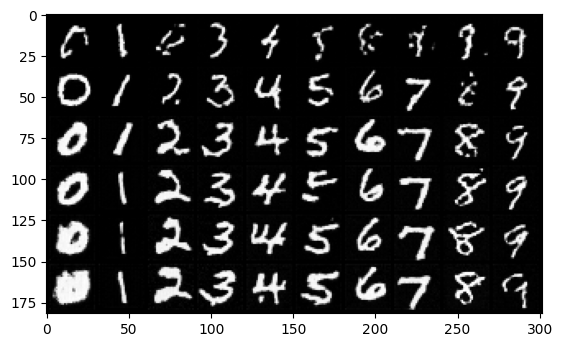

In [ ]:
num_samples = 10
guidance_scales = [0, 1, 5, 8, 10, 15]
all_generated_images = []

for guidance_scale in guidance_scales:
    print(f"Generating with guidance scale: {guidance_scale}")
    classes = torch.arange(num_samples).long().to(device)
    generated_samples = sample_conditional(schedule, conditional_model, classes, batch_size=num_samples, guidance_scale=guidance_scale)
    final_images = generated_samples[-1]
    all_generated_images.append(final_images)

show_images(torch.cat(all_generated_images), nrow=num_samples)
